# Risk, Correlation & Hedging — Homework Solutions
### SPY/SDS, T-Bills, S&P/Gold/Commodities/US Dollar, Weekly Rolling Correlations

This notebook computes every statistic needed to answer Questions 1–17, and states
the selected answer with the supporting numbers directly under each question.


## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda x: f'{x:,.6f}')


---
## Questions 1–4: SPY / SDS and T-Bills

**Data:** `daily_prices_SPY_SDS_SSO.csv` (daily SPY/SDS prices) and `daily_yield_irx.csv`
(13-week T-Bill annualized rate, already expressed as a decimal, i.e. rate/100).

Assume the portfolio (X_SP, X_SD) is fully invested: X_SP + X_SD = 1.


In [2]:
prices = pd.read_csv('daily_prices_SPY_SDS_SSO.csv', parse_dates=['Date']).sort_values('Date').reset_index(drop=True)
ret = prices[['SPY', 'SDS']].pct_change().dropna().reset_index(drop=True)

mean_d = ret.mean()
std_d  = ret.std()
corr_sp_sd = ret['SPY'].corr(ret['SDS'])

print("Daily mean returns:\n", mean_d, "\n")
print("Daily std (risk):\n", std_d, "\n")
print(f"Correlation(SPY,SDS) = {corr_sp_sd:.4f}")


Daily mean returns:
 SPY    0.000639
SDS   -0.001042
dtype: float64 

Daily std (risk):
 SPY   0.011299
SDS   0.022559
dtype: float64 

Correlation(SPY,SDS) = -0.9989


### Question 1 — Zero-risk weights under perfect negative correlation ($\rho=-1$)

For two assets with $\rho = -1$, portfolio variance is a perfect square:

$$\sigma_p^2=(X_{SP}\sigma_{SP}-X_{SD}\sigma_{SD})^2$$

Risk is driven to **zero** by setting $X_{SP}\sigma_{SP}=X_{SD}\sigma_{SD}$ subject to $X_{SP}+X_{SD}=1$, which gives

$$X_{SP}=\dfrac{\sigma_{SD}}{\sigma_{SP}+\sigma_{SD}}\ ,\qquad X_{SD}=\dfrac{\sigma_{SP}}{\sigma_{SP}+\sigma_{SD}}$$

Note the weights are a ratio of **standard deviations**, not variances — the general
minimum-variance formula only collapses to variance ratios when $\rho=0$.


In [3]:
sig_sp, sig_sd = std_d['SPY'], std_d['SDS']

X_SP = sig_sd / (sig_sp + sig_sd)
X_SD = sig_sp / (sig_sp + sig_sd)
print(f"sigma_SPY = {sig_sp:.6f},  sigma_SDS = {sig_sd:.6f}")
print(f"X_SP = {X_SP:.4f},  X_SD = {X_SD:.4f}")

# confirm risk truly collapses to (near) zero given corr is not exactly -1
port = X_SP*ret['SPY'] + X_SD*ret['SDS']
print(f"\nActual correlation is {corr_sp_sd:.4f} (not exactly -1),")
print(f"so the resulting portfolio daily std is small but not exactly zero: {port.std():.6f}")


sigma_SPY = 0.011299,  sigma_SDS = 0.022559
X_SP = 0.6663,  X_SD = 0.3337

Actual correlation is -0.9989 (not exactly -1),
so the resulting portfolio daily std is small but not exactly zero: 0.000346


**Answer: Option D** — $X_{SD}=\dfrac{\sigma_{SP}}{\sigma_{SP}+\sigma_{SD}}$ is exactly the zero-risk
weight derived above (reading the option's denominator as $\sigma_{SP}+\sigma_{SD}$).
- Option A and B use *variance* ratios, which is the min-variance rule only for $\rho=0$, not $\rho=-1$.
- Option C (60/40) is arbitrary and ignores the assets' own volatilities.
- Option E is wrong — the zero-risk allocation is unique and shown above.


### Question 2 — T-Bill rate distribution

In [4]:
irx = pd.read_csv('daily_yield_irx.csv', parse_dates=['Date'])
tbill_mean = irx['^IRX'].mean()
tbill_std  = irx['^IRX'].std()
print(f"T-Bill annualized rate — mean = {tbill_mean:.4%},  std = {tbill_std:.4%}")


T-Bill annualized rate — mean = 2.2151%,  std = 1.8691%


**Answer: Option D** — Std ($\approx 1.87\%$) is less than 2%, and mean ($\approx 2.22\%$) is more than 2%.

### Question 3 — Annualized (mean, std) of the zero-risk SPY/SDS portfolio vs. T-Bills

In [5]:
ann_mean = port.mean() * 252
ann_std  = port.std()  * np.sqrt(252)

print(f"Zero-risk portfolio — annualized mean = {ann_mean:.4%},  annualized std = {ann_std:.4%}")
print(f"T-Bills             — mean = {tbill_mean:.4%},  std = {tbill_std:.4%}")


Zero-risk portfolio — annualized mean = 1.9741%,  annualized std = 0.5488%
T-Bills             — mean = 2.2151%,  std = 1.8691%


**Answer: Option D** — The (X_SP, X_SD) portfolio has **less volatility** ($\approx 0.55\%$ vs. $\approx 1.87\%$)
**and a lower mean** ($\approx 1.97\%$ vs. $\approx 2.22\%$) than the T-Bill rate.


### Question 4 — Reward-to-Risk (mean/std) comparison

In [6]:
rr_port  = ann_mean / ann_std
rr_tbill = tbill_mean / tbill_std
print(f"Reward-to-Risk, zero-risk portfolio = {rr_port:.3f}")
print(f"Reward-to-Risk, T-Bills             = {rr_tbill:.3f}")


Reward-to-Risk, zero-risk portfolio = 3.597
Reward-to-Risk, T-Bills             = 1.185


**Answer: Option C** — The minimum-risk SPY/SDS portfolio delivers a materially **higher**
reward-to-risk ratio ($\approx 3.6$) than investing in T-Bills ($\approx 1.2$), even though its
absolute mean return is lower — because its risk is reduced by even more.


---
## Questions 5–10: S&P 500 / Bonds / Gold / Commodities / US Dollar

**Data:** `sp_gold_commodities_usd.csv` — this file already contains **monthly** returns
(month-end dates) for the five series, so `df0` itself is the return dataframe.


In [7]:
df0 = pd.read_csv('sp_gold_commodities_usd.csv')
df = df0.dropna().copy().reset_index(drop=True)

print("Shape:", df.shape)
print("Start date:", df['Date'].min(), " End date:", df['Date'].max())
assert df.shape == (230, 6)


Shape: (230, 6)
Start date: 2007-04-30  End date: 2026-05-31


In [8]:
cols4 = ['S&P 500', 'Bonds', 'Gold', 'Commodities']
corr_matrix = df[cols4].corr()
std_assets  = df[cols4].std()

print("Correlation matrix:\n", corr_matrix, "\n")
print("Std of each asset (monthly):\n", std_assets)


Correlation matrix:
              S&P 500     Bonds     Gold  Commodities
S&P 500     1.000000  0.232695 0.076839     0.432896
Bonds       0.232695  1.000000 0.403843    -0.140090
Gold        0.076839  0.403843 1.000000     0.160647
Commodities 0.432896 -0.140090 0.160647     1.000000 

Std of each asset (monthly):
 S&P 500       0.045037
Bonds         0.012547
Gold          0.049858
Commodities   0.066729
dtype: float64


### Question 5 — Beta of Gold w.r.t. S&P 500

In [9]:
cov4 = df[cols4].cov()
beta_gold = cov4.loc['Gold', 'S&P 500'] / cov4.loc['S&P 500', 'S&P 500']
corr_gold_sp = df['Gold'].corr(df['S&P 500'])
print(f"Beta(Gold, S&P500) = {beta_gold:.4f}")
print(f"Corr(Gold, S&P500) = {corr_gold_sp:.4f}")


Beta(Gold, S&P500) = 0.0851
Corr(Gold, S&P500) = 0.0768


**Answer: Option E** — Beta $\approx 0.085$: it is **positive but well below 0.1**.
(Note it is *not* equal to the correlation — Option A is wrong because beta also scales
by the ratio $\sigma_{Gold}/\sigma_{SP}$.)


### Question 6 — Beta of US Dollar w.r.t. S&P 500 (monthly)

In [10]:
cov_usd = df[['S&P 500', 'US Dollar']].cov()
beta_usd = cov_usd.loc['US Dollar', 'S&P 500'] / cov_usd.loc['S&P 500', 'S&P 500']
corr_usd = df['US Dollar'].corr(df['S&P 500'])
print(f"Beta(US Dollar, S&P500) = {beta_usd:.4f}")
print(f"Corr(US Dollar, S&P500) = {corr_usd:.4f}")


Beta(US Dollar, S&P500) = -0.2257
Corr(US Dollar, S&P500) = -0.4552


**Answer: Option C** — Beta $\approx -0.226$, which is **more than $-0.25$ and less than $-0.20$**.

### Question 7 — Minimum-variance weight in Gold (S&P 500 + Gold portfolio)

General two-asset minimum-variance weight (no restriction on correlation):

$$w_{Gold}=\dfrac{\sigma_{SP}^2-\sigma_{SP,Gold}}{\sigma_{SP}^2+\sigma_{Gold}^2-2\sigma_{SP,Gold}}$$


In [11]:
sig_sp2, sig_gold2 = df['S&P 500'].std(), df['Gold'].std()
cov_sp_gold = cov4.loc['S&P 500', 'Gold']

w_gold = (sig_sp2**2 - cov_sp_gold) / (sig_sp2**2 + sig_gold2**2 - 2*cov_sp_gold)
w_sp_g = 1 - w_gold
print(f"w_S&P500 = {w_sp_g:.4f},   w_Gold = {w_gold:.4f}")


w_S&P500 = 0.5549,   w_Gold = 0.4451


**Answer: Option C** — The minimum-variance weight in Gold is positive and $\approx 0.45$.

### Question 8 — Risk of that minimum-variance (S&P 500, Gold) portfolio

In [12]:
port_var_g = w_sp_g**2*sig_sp2**2 + w_gold**2*sig_gold2**2 + 2*w_sp_g*w_gold*cov_sp_gold
port_std_g = np.sqrt(port_var_g)

print(f"Monthly variance   = {port_var_g:.6f}   (this matches Option A's '~0.0012', but that's VARIANCE not std)")
print(f"Monthly std         = {port_std_g:.6f}")
print(f"Annualized std       (std * sqrt(12)) = {port_std_g*np.sqrt(12):.4f}")
print(f"Naively 'annualized' variance*12       = {port_var_g*12:.4f}   (matches Option B's '~0.0144', but that's an incorrect annualization)")


Monthly variance   = 0.001202   (this matches Option A's '~0.0012', but that's VARIANCE not std)
Monthly std         = 0.034673
Annualized std       (std * sqrt(12)) = 0.1201
Naively 'annualized' variance*12       = 0.0144   (matches Option B's '~0.0144', but that's an incorrect annualization)


**Answer: Option C** — Correctly annualizing the *standard deviation* using $\sqrt{12}$ gives
$\approx 0.12$. Options A and B are numerically present in the calculation but mislabel
**monthly variance** ($\approx 0.0012$) and **variance $\times 12$** ($\approx 0.0144$) as if they were
standard deviations — a common error. The properly annualized std is $\approx 0.12$.


### Question 9 — Minimum-variance allocation to US Equity (S&P 500 + US Dollar)

In [13]:
sig_usd2 = df['US Dollar'].std()
cov_sp_usd = df[['S&P 500','US Dollar']].cov().loc['S&P 500','US Dollar']

w_usd = (sig_sp2**2 - cov_sp_usd) / (sig_sp2**2 + sig_usd2**2 - 2*cov_sp_usd)
w_sp_u = 1 - w_usd
print(f"w_S&P500 = {w_sp_u:.4f},   w_US Dollar = {w_usd:.4f}")


w_S&P500 = 0.2778,   w_US Dollar = 0.7222


**Answer: Option D** — The minimum-variance weight allocated to US equity is $\approx 0.28$.

### Question 10 — Lowest risk: (S&P500, US Dollar) vs. (S&P500, Gold)

In [14]:
port_var_u = w_sp_u**2*sig_sp2**2 + w_usd**2*sig_usd2**2 + 2*w_sp_u*w_usd*cov_sp_usd
port_std_u = np.sqrt(port_var_u)

print(f"Min-var std, (S&P500, US Dollar): monthly = {port_std_u:.4f},  annualized = {port_std_u*np.sqrt(12):.4f}")
print(f"Min-var std, (S&P500, Gold)     : monthly = {port_std_g:.4f},  annualized = {port_std_g*np.sqrt(12):.4f}")


Min-var std, (S&P500, US Dollar): monthly = 0.0153,  annualized = 0.0529
Min-var std, (S&P500, Gold)     : monthly = 0.0347,  annualized = 0.1201


**Answer: Option E (C and D)** — The (S&P500, US Dollar) combination achieves a **lower** minimum
std ($\approx 0.0153$ monthly) than the (S&P500, Gold) combination ($\approx 0.0347$ monthly), and its
monthly value is indeed $\approx 0.015$.


---
## Questions 11–14: 52-Week Rolling Correlations & Hedging

**Data:** `sp_bonds_gold_commodities_US__weekly_px.csv` — weekly prices, converted to weekly returns.


In [15]:
wk = pd.read_csv('sp_bonds_gold_commodities_US__weekly_px.csv', parse_dates=['Date']).sort_values('Date')
wk = wk.dropna().reset_index(drop=True)

wret = wk[['S&P_500','Gold','US_Dollar','Commodities']].pct_change().dropna().reset_index(drop=True)
wret['Date'] = wk['Date'].iloc[1:].values
wret = wret.reset_index(drop=True)

roll_gold = wret['Gold'].rolling(52).corr(wret['S&P_500'])
roll_usd  = wret['US_Dollar'].rolling(52).corr(wret['S&P_500'])

rc = pd.DataFrame({'Date': wret['Date'], 'roll_gold': roll_gold, 'roll_usd': roll_usd}).dropna().reset_index(drop=True)
rc.describe()


,Date,roll_gold,roll_usd
count,949,949.000000,949.000000
mean,2017-05-05 00:00:00,0.058519,-0.407601
min,2008-04-04 00:00:00,-0.652392,-0.924203
25%,2012-10-19 00:00:00,-0.171456,-0.654659
50%,2017-05-05 00:00:00,0.101214,-0.510516
75%,2021-11-19 00:00:00,0.271238,-0.204812
max,2026-06-05 00:00:00,0.697227,0.597267
std,NaN,0.285234,0.317265


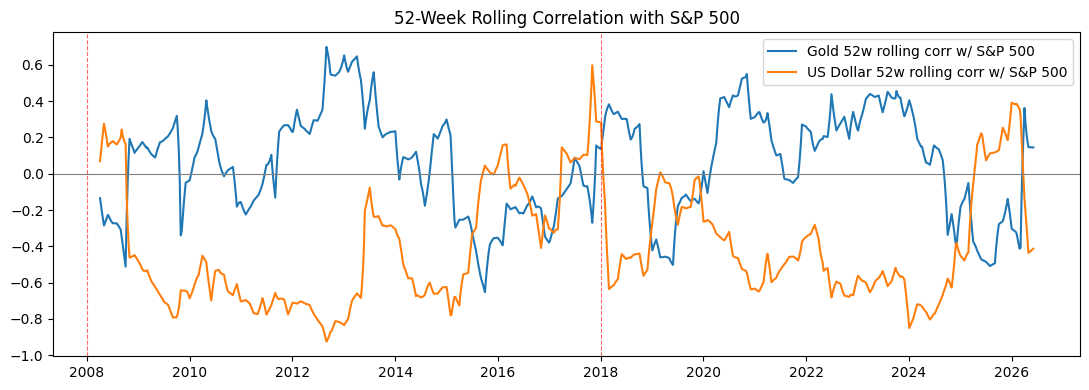

In [16]:
fig, ax = plt.subplots(figsize=(11,4))
ax.plot(rc['Date'], rc['roll_gold'], label='Gold 52w rolling corr w/ S&P 500')
ax.plot(rc['Date'], rc['roll_usd'], label='US Dollar 52w rolling corr w/ S&P 500')
ax.axhline(0, color='gray', lw=0.8)
for yr in [2008, 2018]:
    ax.axvline(pd.Timestamp(f'{yr}-01-01'), color='red', ls='--', lw=0.8, alpha=0.6)
ax.legend(); ax.set_title('52-Week Rolling Correlation with S&P 500')
plt.tight_layout(); plt.show()


### Question 11 — Descriptive statistics of the rolling correlations

In [17]:
print(rc[['roll_gold','roll_usd']].describe(), "\n")

mean_usd, median_usd = rc['roll_usd'].mean(), rc['roll_usd'].median()
print(f"US Dollar rolling corr — mean = {mean_usd:.4f}, median = {median_usd:.4f}  (median < mean? {median_usd < mean_usd})")

rc['year'] = rc['Date'].dt.year
print("\nYearly average US Dollar rolling correlation:")
print(rc.groupby('year')['roll_usd'].mean())


       roll_gold   roll_usd
count 949.000000 949.000000
mean    0.058519  -0.407601
std     0.285234   0.317265
min    -0.652392  -0.924203
25%    -0.171456  -0.654659
50%     0.101214  -0.510516
75%     0.271238  -0.204812
max     0.697227   0.597267 

US Dollar rolling corr — mean = -0.4076, median = -0.5105  (median < mean? True)

Yearly average US Dollar rolling correlation:
year
2008    0.000508
2009   -0.649984
2010   -0.592513
2011   -0.721766
2012   -0.789512
2013   -0.422449
2014   -0.585825
2015   -0.353297
2016   -0.104684
2017    0.077541
2018   -0.444814
2019   -0.121845
2020   -0.410326
2021   -0.512790
2022   -0.533677
2023   -0.592871
2024   -0.685347
2025    0.019235
2026    0.020551
Name: roll_usd, dtype: float64


**Answer: Option E (A and C)**
- **A is true:** the yearly averages show the US Dollar correlation dropping sharply right after
  2008 (from $\approx 0.0$ in 2008 to $\approx -0.65$ in 2009) and again after 2018 (from
  $\approx +0.08$ in 2017 to $\approx -0.44$ in 2018).
- **B is false:** the correlation ranges well beyond $\pm 0.5$ (min $\approx -0.92$).
- **C is true:** the median ($\approx -0.51$) is lower (more negative) than the mean ($\approx -0.41$),
  i.e. median < mean.
- Since B is false, "All of the above" (D) cannot be correct — only **A and C**.


### Question 12 — Three-state market regime (25th/75th percentile of US Dollar rolling correlation)

In [18]:
q25, q75 = rc['roll_usd'].quantile([0.25, 0.75])
print(f"q25 = {q25:.4f},  q75 = {q75:.4f}")

full = wret.merge(rc[['Date','roll_usd','roll_gold']], on='Date')

def regime(x):
    if x <= q25: return 'Low correlation'
    elif x >= q75: return 'High correlation'
    else: return 'Mid correlation'

full['regime'] = full['roll_usd'].apply(regime)
stats_by_regime = full.groupby('regime')['S&P_500'].agg(['count','mean','median','std'])
stats_by_regime


q25 = -0.6547,  q75 = -0.2048


,count,mean,median,std
regime,,,,
High correlation,238,0.001929,0.002876,0.008875
Low correlation,238,0.003515,0.004811,0.008730
Mid correlation,473,0.001801,0.003892,0.012061


**Answer: Option C** — Median S&P weekly returns differ meaningfully across regimes, and are
**highest in the low-correlation regime** ($\approx 0.0048$, vs. $\approx 0.0029$ in the high-correlation
regime and $\approx 0.0039$ in the mid regime) — i.e., S&P returns tend to be strongest precisely
when the US Dollar is *most* negatively correlated with equities. (Option B is false: the highest
median is in the *low*, not high, correlation regime.)


### Question 13 — Hedging $2,000,000 of SPY with UUP (US Dollar)

The hedge ratio is the regression beta of the US Dollar on the S&P 500,
$\beta = \text{Cov}(SP,USD)/\text{Var}(SP)$: the dollar amount of UUP needed per dollar of SPY exposure.


In [19]:
cov_sp_usd_w = wret[['S&P_500','US_Dollar']].cov()
beta_usd_on_sp = cov_sp_usd_w.loc['S&P_500','US_Dollar'] / cov_sp_usd_w.loc['S&P_500','S&P_500']
corr_sp_usd_w = wret['S&P_500'].corr(wret['US_Dollar'])
r2_usd = corr_sp_usd_w**2

port_val = 2_000_000
hedge_amt = beta_usd_on_sp * port_val

print(f"Beta(US Dollar on S&P500) = {beta_usd_on_sp:.4f}")
print(f"Hedge notional = beta * portfolio value = {hedge_amt:,.0f}")
print(f"Corr(S&P500, US Dollar) = {corr_sp_usd_w:.4f},  R^2 = {r2_usd:.4f}")


Beta(US Dollar on S&P500) = -0.2259
Hedge notional = beta * portfolio value = -451,844
Corr(S&P500, US Dollar) = -0.4582,  R^2 = 0.2100


**Answer: Option E (B and D)**
- Because US Dollar is **negatively** correlated with the S&P 500, hedging a **long** SPY position
  requires going **long** roughly $\beta \times \$2{,}000{,}000 \approx \$452{,}000$ of UUP (a long UUP
  position rises when SPY falls, offsetting losses) — matching **Option B** ("long about \$440,000").
- $R^2 \approx 0.21$, so at most **about 20%** of S&P return variance can be eliminated with this
  hedge — matching **Option D**, and ruling out Option C's claim of 50%.


### Question 14 — Best single-asset hedge among Gold, Commodities, US Dollar

In [20]:
for c in ['Gold','Commodities','US_Dollar']:
    corr_c = wret['S&P_500'].corr(wret[c])
    print(f"{c:12s}  corr = {corr_c:+.4f}   R^2 = {corr_c**2:.4f}")


Gold          corr = +0.0977   R^2 = 0.0095
Commodities   corr = +0.4546   R^2 = 0.2067
US_Dollar     corr = -0.4582   R^2 = 0.2100


**Answer: Option B** — Hedge effectiveness is governed by **R², not by the sign of the
correlation** (you can short a positively correlated asset just as effectively as go long a
negatively correlated one). By this measure, US Dollar ($R^2\approx 0.210$) and Commodities
($R^2\approx 0.207$) are nearly tied — Commodities (positively correlated) achieves essentially
the same variance reduction as the US Dollar (negatively correlated), which is exactly why
Option A's reasoning ("must look for negative correlation") is not the correct rule — R² is.


---
## Questions 15–17: Global Minimum-Variance Portfolio (S&P 500, Gold, Commodities, US Dollar)

Using the covariance matrix of these four assets' monthly returns (from the `df` built in Q5),
with short sales allowed, the fully-invested global minimum-variance (GMV) weights are:

$$w^{*}=\dfrac{\Sigma^{-1}\mathbf{1}}{\mathbf{1}^{\top}\Sigma^{-1}\mathbf{1}}$$


In [21]:
cols_gmv = ['S&P 500','Gold','Commodities','US Dollar']
cov_gmv = df[cols_gmv].cov()

ones = np.ones(len(cols_gmv))
inv_cov = np.linalg.inv(cov_gmv.values)
w_gmv = inv_cov @ ones / (ones @ inv_cov @ ones)
w_gmv = pd.Series(w_gmv, index=cols_gmv)

print("Global minimum-variance weights:\n", w_gmv, "\n")

gmv_mean = df[cols_gmv].mean().values @ w_gmv.values
gmv_var  = w_gmv.values @ cov_gmv.values @ w_gmv.values
gmv_std  = np.sqrt(gmv_var)

print(f"GMV portfolio — monthly mean = {gmv_mean:.5f}, monthly std = {gmv_std:.5f}")
print(f"GMV portfolio — annualized mean = {gmv_mean*12:.4f}, annualized std = {gmv_std*np.sqrt(12):.4f}")


Global minimum-variance weights:
 S&P 500       0.164607
Gold          0.158501
Commodities   0.046224
US Dollar     0.630668
dtype: float64 

GMV portfolio — monthly mean = 0.00415, monthly std = 0.01152
GMV portfolio — annualized mean = 0.0498, annualized std = 0.0399


### Question 15 — Which asset has the highest weight?

**Answer: Option D** — US Dollar receives by far the largest weight ($\approx 0.63$), because it
has both low variance and negative covariance with the other three assets, making it especially
valuable for variance reduction.


### Question 16 — Reward-to-risk (mean/std) comparison

In [22]:
rr_assets = df[cols_gmv].mean() / df[cols_gmv].std()
rr_gmv = gmv_mean / gmv_std

print("Reward-to-risk of each individual asset:\n", rr_assets, "\n")
print(f"Reward-to-risk of the GMV portfolio = {rr_gmv:.4f}")


Reward-to-risk of each individual asset:
 S&P 500       0.220555
Gold          0.186451
Commodities   0.017268
US Dollar     0.070396
dtype: float64 

Reward-to-risk of the GMV portfolio = 0.3605


**Answer: Option A** — The global minimum-variance portfolio has the **highest** reward-to-risk
ratio ($\approx 0.36$), exceeding even the best individual asset, S&P 500 ($\approx 0.22$) — the
benefit of diversification more than compensates for the assets' lower individual returns.


### Question 17 — Growth of $1 invested in the GMV portfolio vs. S&P 500

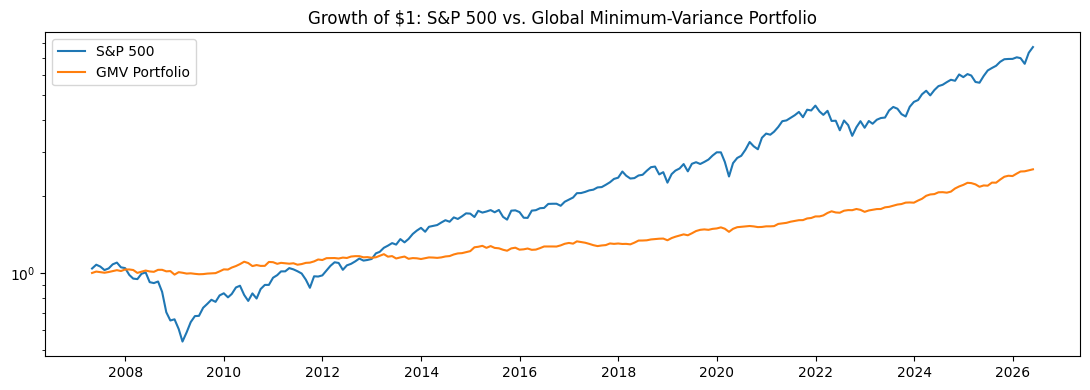

Final value of $1 in S&P 500:      7.70
Final value of $1 in GMV portfolio: 2.56


In [23]:
growth_sp = (1 + df['S&P 500']).cumprod()
port_ret_gmv = (df[cols_gmv] * w_gmv.values).sum(axis=1)
growth_gmv = (1 + port_ret_gmv).cumprod()

fig, ax = plt.subplots(figsize=(11,4))
ax.plot(pd.to_datetime(df['Date']), growth_sp, label='S&P 500')
ax.plot(pd.to_datetime(df['Date']), growth_gmv, label='GMV Portfolio')
ax.set_yscale('log')
ax.legend(); ax.set_title('Growth of $1: S&P 500 vs. Global Minimum-Variance Portfolio')
plt.tight_layout(); plt.show()

print(f"Final value of $1 in S&P 500:      {growth_sp.iloc[-1]:.2f}")
print(f"Final value of $1 in GMV portfolio: {growth_gmv.iloc[-1]:.2f}")


**Answer: Option B** — Despite the S&P 500's much higher volatility (and the resulting
volatility drag on its compounded return), it still ends up **far ahead** of the low-volatility
GMV portfolio in cumulative growth ($\approx \$7.70$ vs. $\approx \$2.56$ per \$1 invested) — a
high enough arithmetic mean return can outrun even a heavy volatility drag over this horizon.


---
## Question 18

In [24]:
print("jupyter notebook is submitted")


jupyter notebook is submitted
